In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from mpl_toolkits.mplot3d import Axes3D 

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

file_path = "../data/sales_data_sample.csv"
df = pd.read_csv(file_path,encoding="Unicode_escape")

In [3]:

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

print(f"Transactions: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['ORDERDATE'].min().date()}  ->  {df['ORDERDATE'].max().date()}")
print(f"Unique customers: {df['CUSTOMERNAME'].nunique()}")
print(f"Unique orders: {df['ORDERNUMBER'].nunique()}")

df[['ORDERDATE', 'ORDERNUMBER', 'CUSTOMERNAME', 'SALES']].head()

Transactions: 2,823 rows, 25 columns
Date range: 2003-01-06  ->  2005-05-31
Unique customers: 92
Unique orders: 307


,ORDERDATE,ORDERNUMBER,CUSTOMERNAME,SALES
0,2003-02-24,10107,Land of Toys Inc.,2871.00
1,2003-05-07,10121,Reims Collectables,2765.90
2,2003-07-01,10134,Lyon Souveniers,3884.34
3,2003-08-25,10145,Toys4GrownUps.com,3746.70
4,2003-10-10,10159,Corporate Gift Ideas Co.,5205.27


In [4]:
reference_date = df['ORDERDATE'].max() + timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

Reference date: 2005-06-01


In [5]:
rfm = df.groupby('CUSTOMERNAME').agg(
    Recency=('ORDERDATE', lambda x: (reference_date - x.max()).days),
    Frequency=('ORDERNUMBER', 'nunique'),
    Monetary=('SALES', 'sum')
).reset_index()

print(f"Customers in RFM table: {rfm.shape[0]}")
rfm.head()

Customers in RFM table: 92


,CUSTOMERNAME,Recency,Frequency,Monetary
0,"AV Stores, Co.",196,3,157807.81
1,Alpha Cognac,65,3,70488.44
2,Amica Models & Co.,265,2,94117.26
3,"Anna's Decorations, Ltd",84,4,153996.13
4,Atelier graphique,188,3,24179.96


In [6]:
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)


,Recency,Frequency,Monetary
count,92.00,92.00,92.00
mean,182.83,3.34,109050.31
std,131.42,2.92,110308.61
min,1.00,1.00,9129.35
25%,81.25,2.00,70129.43
50%,186.00,3.00,86522.61
75%,230.25,3.00,120575.88
max,509.00,26.00,912294.11


In [7]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1]).astype(int)


rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)


rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)

rfm[['CUSTOMERNAME', 'Recency', 'R_Score', 'Frequency', 'F_Score', 'Monetary', 'M_Score']].head()


,CUSTOMERNAME,Recency,R_Score,Frequency,F_Score,Monetary,M_Score
0,"AV Stores, Co.",196,2,3,2,157807.81,4
1,Alpha Cognac,65,4,3,2,70488.44,2
2,Amica Models & Co.,265,1,2,1,94117.26,3
3,"Anna's Decorations, Ltd",84,3,4,4,153996.13,4
4,Atelier graphique,188,2,3,2,24179.96,1


In [8]:
rfm['RFM_Segment'] = (
    rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm[['CUSTOMERNAME', 'R_Score', 'F_Score', 'M_Score', 'RFM_Segment', 'RFM_Score']].sort_values(
    'RFM_Score', ascending=False
).head(10)


,CUSTOMERNAME,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
27,Danish Wholesale Imports,4,4,4,444,12
55,Mini Gifts Distributors Ltd.,4,4,4,444,12
33,Euro Shopping Channel,4,4,4,444,12
28,Diecast Classics Inc.,4,4,4,444,12
66,Reims Collectables,4,4,4,444,12
70,Salzburg Collectables,4,4,4,444,12
75,Souveniers And Things Co.,4,4,4,444,12
81,The Sharp Gifts Warehouse,4,4,4,444,12
44,La Rochelle Gifts,4,4,4,444,12
3,"Anna's Decorations, Ltd",3,4,4,344,11


In [9]:
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r == 1 and f == 1 and m == 1:
        return 'Lost'
    elif r >= 3 and f <= 2:
        return 'New/Promising'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

rfm['Segment'].value_counts()

Segment
Needs Attention    37
Loyal              17
New/Promising      11
Lost               11
Champions           9
At Risk             7
Name: count, dtype: int64

In [10]:
summary = rfm.groupby('Segment').agg(
    Customer_Count=('CUSTOMERNAME', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Monetary=('Monetary', 'sum')
).round(2)

summary['Pct_of_Customers'] = (summary['Customer_Count'] / summary['Customer_Count'].sum() * 100).round(1)
summary['Pct_of_Revenue'] = (summary['Total_Monetary'] / summary['Total_Monetary'].sum() * 100).round(1)

summary = summary.sort_values('Avg_Monetary', ascending=False)
summary

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Pct_of_Customers,Pct_of_Revenue
Segment,,,,,,,
Champions,9,19.44,8.11,290097.74,2610879.63,9.8,26.0
Loyal,17,110.29,3.59,132894.92,2259213.63,18.5,22.5
At Risk,7,239.00,3.29,125489.83,878428.84,7.6,8.8
Needs Attention,37,219.54,2.62,80049.75,2961840.76,40.2,29.5
New/Promising,11,91.73,2.91,67839.01,746229.09,12.0,7.4
Lost,11,360.45,1.91,52366.99,576036.90,12.0,5.7


In [11]:
print(f"Total customers: {rfm.shape[0]}")
print(f"Total revenue: ${rfm['Monetary'].sum():,.2f}")
print()
for seg, row in summary.iterrows():
    print(f"{seg:16s} | {int(row['Customer_Count']):3d} customers "
          f"({row['Pct_of_Customers']:5.1f}%) | "
          f"{row['Pct_of_Revenue']:5.1f}% of revenue | "
          f"avg spend ${row['Avg_Monetary']:,.0f}")

Total customers: 92
Total revenue: $10,032,628.85

Champions        |   9 customers (  9.8%) |  26.0% of revenue | avg spend $290,098
Loyal            |  17 customers ( 18.5%) |  22.5% of revenue | avg spend $132,895
At Risk          |   7 customers (  7.6%) |   8.8% of revenue | avg spend $125,490
Needs Attention  |  37 customers ( 40.2%) |  29.5% of revenue | avg spend $80,050
New/Promising    |  11 customers ( 12.0%) |   7.4% of revenue | avg spend $67,839
Lost             |  11 customers ( 12.0%) |   5.7% of revenue | avg spend $52,367


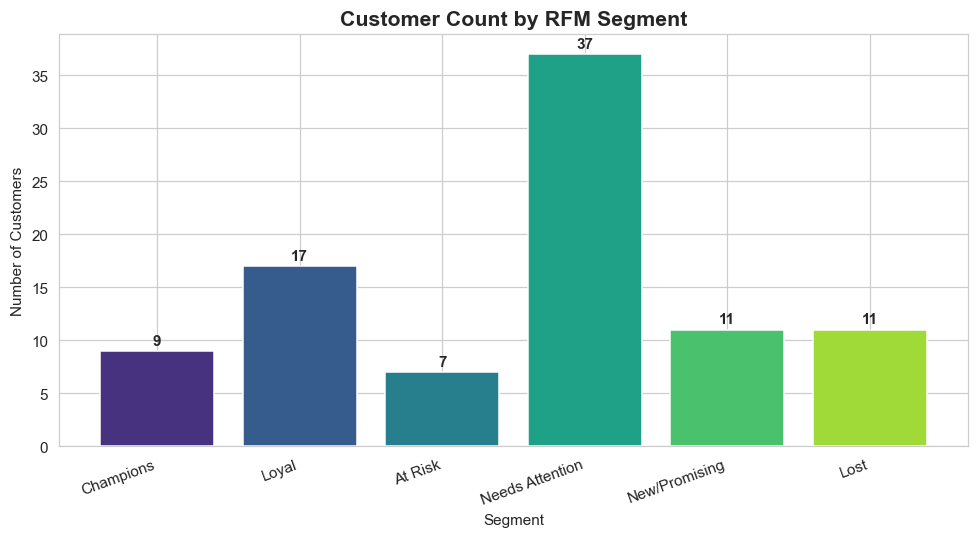

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

seg_order = summary.index.tolist()
colors = sns.color_palette('viridis', len(seg_order))

counts = rfm['Segment'].value_counts().reindex(seg_order)
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3, str(val),
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Customer Count by RFM Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('segment_sizes_bar.png', dpi=150, bbox_inches='tight')
plt.show()

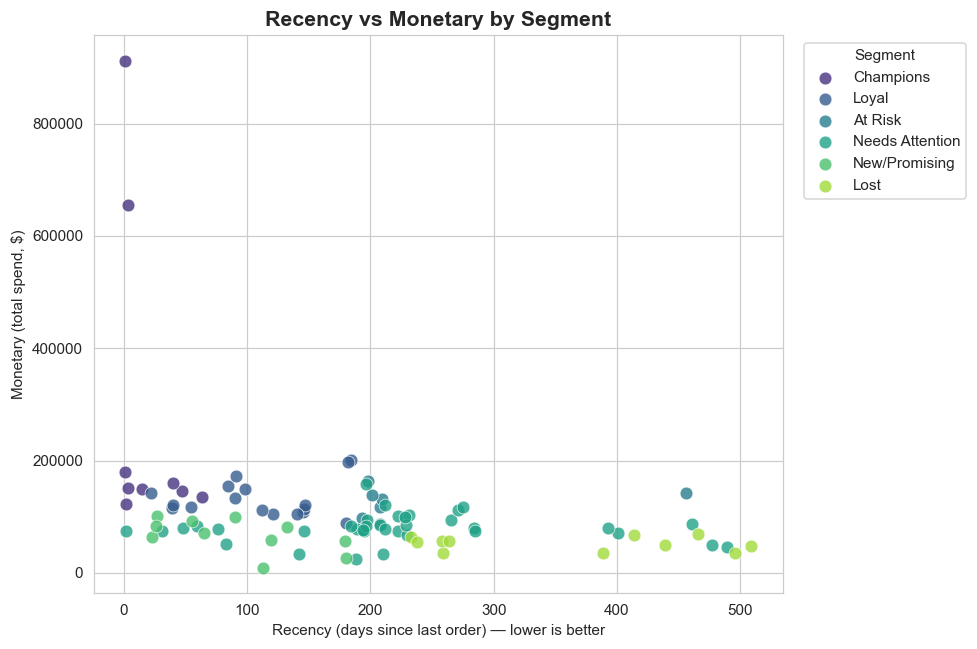

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

palette = dict(zip(seg_order, sns.color_palette('viridis', len(seg_order))))

for seg in seg_order:
    sub = rfm[rfm['Segment'] == seg]
    ax.scatter(sub['Recency'], sub['Monetary'], label=seg, s=70,
               alpha=0.8, color=palette[seg], edgecolor='white', linewidth=0.5)

ax.set_title('Recency vs Monetary by Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Recency (days since last order) — lower is better')
ax.set_ylabel('Monetary (total spend, $)')
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('recency_vs_monetary_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


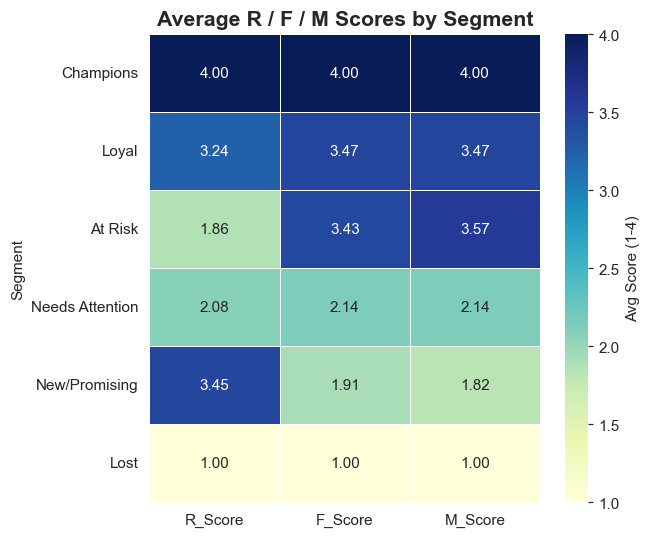

In [14]:
score_summary = rfm.groupby('Segment')[['R_Score', 'F_Score', 'M_Score']].mean().reindex(seg_order)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(score_summary, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Avg Score (1-4)'}, ax=ax)
ax.set_title('Average R / F / M Scores by Segment', fontsize=14, fontweight='bold')
ax.set_ylabel('Segment')
plt.tight_layout()
plt.savefig('rfm_score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

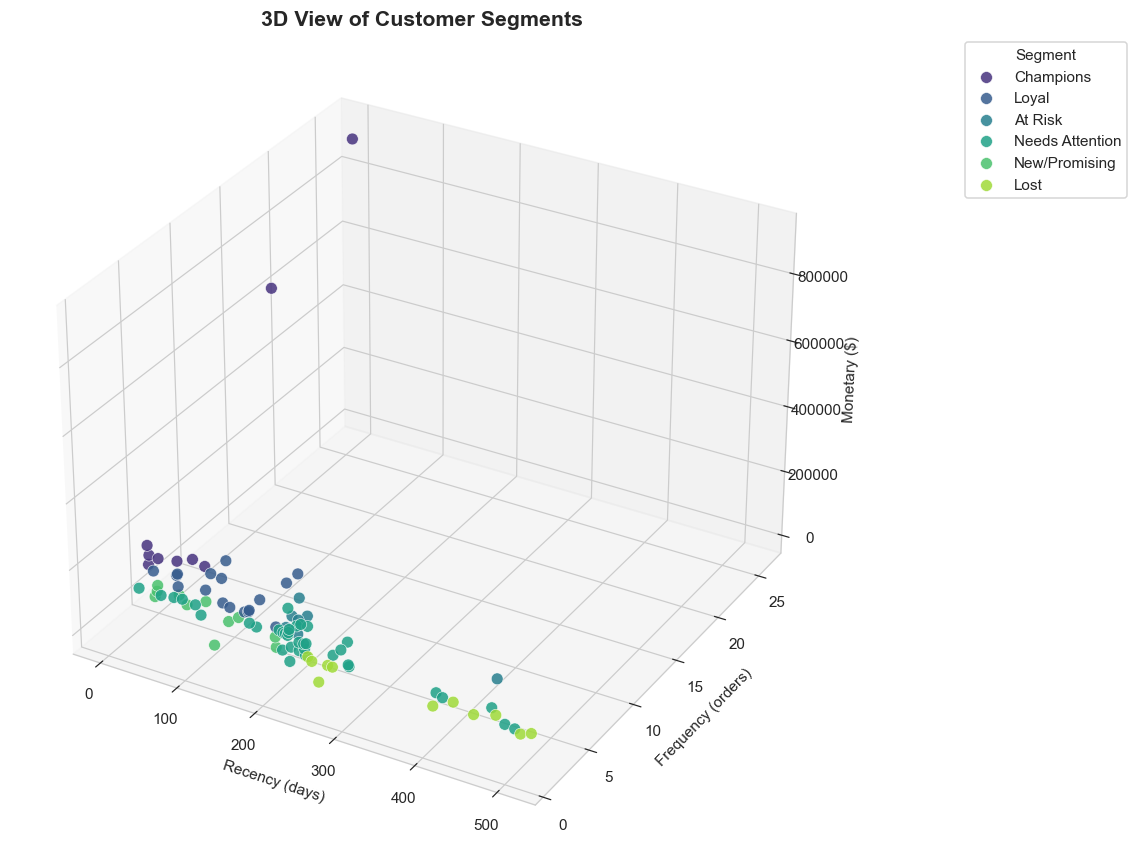

In [15]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for seg in seg_order:
    sub = rfm[rfm['Segment'] == seg]
    ax.scatter(sub['Recency'], sub['Frequency'], sub['Monetary'],
               label=seg, s=60, alpha=0.85, color=palette[seg], edgecolor='white', linewidth=0.4)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary ($)')
ax.set_title('3D View of Customer Segments', fontsize=14, fontweight='bold')
ax.legend(title='Segment', bbox_to_anchor=(1.15, 1), loc='upper left')
plt.tight_layout()
plt.savefig('rfm_3d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
export_cols = ['CUSTOMERNAME', 'Recency', 'Frequency', 'Monetary',
               'R_Score', 'F_Score', 'M_Score', 'RFM_Segment', 'RFM_Score', 'Segment']

rfm_export = rfm[export_cols].sort_values('RFM_Score', ascending=False)
rfm_export.to_csv('rfm_customer_segments.csv', index=False)

print(f"{rfm_export.shape[0]}  rfm_customer_segments.csv")
rfm_export.head()

92  rfm_customer_segments.csv


,CUSTOMERNAME,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Segment
27,Danish Wholesale Imports,47,5,145041.60,4,4,4,444,12,Champions
55,Mini Gifts Distributors Ltd.,3,17,654858.06,4,4,4,444,12,Champions
33,Euro Shopping Channel,1,26,912294.11,4,4,4,444,12,Champions
28,Diecast Classics Inc.,2,4,122138.14,4,4,4,444,12,Champions
66,Reims Collectables,63,5,135042.94,4,4,4,444,12,Champions
